# TP de synthèse — Analyse factorielle des correspondances

**Binôme :** Sellami Mohamed Amine et Abdesselam Meriem — G3 

## Rappel des notations utilisées

On considère le tableau de contingence :

$$
K = (k_{ij})_{1 \leq i \leq p,\;1 \leq j \leq q}
$$

où :

- \(p\) est le nombre de modalités lignes : les **raisons** ;
- \(q\) est le nombre de modalités colonnes : les **métiers** ;
- \(k_{ij}\) est l'effectif observé pour la raison \(i\) et le métier \(j\).

L'effectif total est :

$$
N = \sum_{i=1}^{p}\sum_{j=1}^{q} k_{ij}
$$

La matrice des fréquences relatives est :

$$
F = \frac{K}{N}
$$

Les masses lignes et colonnes sont :

$$
r_i = f_{i+} = \sum_{j=1}^{q} f_{ij}
$$

$$
c_j = f_{+j} = \sum_{i=1}^{p} f_{ij}
$$

## Formules principales de l'AFC

### Profils lignes

Le profil ligne de la modalité \(i\) est donné par :

$$
(X_L)_{ij} = \frac{f_{ij}}{r_i}
$$

### Profils colonnes

Le profil colonne de la modalité \(j\) est donné par :

$$
(X_C)_{ij} = \frac{f_{ij}}{c_j}
$$

### Matrice standardisée

L'AFC consiste à diagonaliser la matrice des écarts à l'indépendance standardisés :

$$
S = D_r^{-\frac{1}{2}}\left(F - r c^\top\right)D_c^{-\frac{1}{2}}
$$

avec :

$$
D_r = \operatorname{diag}(r_1,\ldots,r_p)
$$

$$
D_c = \operatorname{diag}(c_1,\ldots,c_q)
$$

### Décomposition en valeurs singulières

$$
S = U \Delta V^\top
$$

Les valeurs propres sont :

$$
\lambda_k = \delta_k^2
$$

où \(\delta_k\) est la \(k^{ème}\) valeur singulière.

### Coordonnées principales

Les facteurs lignes sont :

$$
\Phi = D_r^{-\frac{1}{2}}U\Delta
$$

Les facteurs colonnes sont :

$$
\Psi = D_c^{-\frac{1}{2}}V\Delta
$$

## 0. Importation des bibliothèques

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
pd.options.display.float_format = "{:.4f}".format
np.set_printoptions(precision=4, suppress=True)

### Explication après exécution

Cette cellule importe les bibliothèques nécessaires :

- `numpy` pour les calculs matriciels ;
- `pandas` pour afficher les résultats sous forme de tableaux ;
- `matplotlib` pour les représentations graphiques ;
- `display` et `Markdown` pour améliorer l'affichage dans le notebook.

Aucune analyse n'est encore effectuée dans cette cellule.

## 1. Déclaration du tableau de contingence

In [2]:
raisons = ["Logement", "Santé", "Argent", "Guerre", "Travail", "Choix", "Chômage"]

metiers = ["Cadre", "Libre", "Employé S", "Responsable", "Ouvrier", "Technicien", "Agriculteur"]

K = np.array([
    [22, 89, 71, 27, 22, 40, 24],
    [1, 24, 23, 29, 8, 10, 13],
    [20, 98, 49, 22, 26, 46, 22],
    [4, 7, 7, 6, 1, 3, 5],
    [12, 117, 121, 65, 24, 57, 48],
    [11, 79, 60, 41, 11, 34, 43],
    [6, 22, 26, 23, 7, 14, 13]
], dtype=float)

df_K = pd.DataFrame(K, index=raisons, columns=metiers)
N = K.sum()

print("Tableau de contingence K :")
display(df_K.astype(int))
print("Effectif total N =", int(N))

Tableau de contingence K :


,Cadre,Libre,Employé S,Responsable,Ouvrier,Technicien,Agriculteur
Logement,22,89,71,27,22,40,24
Santé,1,24,23,29,8,10,13
Argent,20,98,49,22,26,46,22
Guerre,4,7,7,6,1,3,5
Travail,12,117,121,65,24,57,48
Choix,11,79,60,41,11,34,43
Chômage,6,22,26,23,7,14,13


Effectif total N = 1553


### Explication après exécution

Le tableau affiché est le tableau de contingence \(K\).  
Chaque ligne correspond à une **raison** de non-parentalité et chaque colonne correspond à un **métier** ou une situation sociale.

L'effectif total \(N\) représente le nombre total de réponses observées dans l'enquête :

$$
N = \sum_{i=1}^{p}\sum_{j=1}^{q} k_{ij}
$$

Ce tableau est le point de départ de toute l'analyse factorielle des correspondances.

## 2. Question 1 — Détermination des profils lignes et colonnes

### 2.1 Matrice des fréquences relatives

La matrice des fréquences relatives est définie par :

$$
F = \frac{K}{N}
$$

In [3]:
F = K / N

r = F.sum(axis=1)
c = F.sum(axis=0)

df_F = pd.DataFrame(F, index=raisons, columns=metiers)
df_masses_lignes = pd.DataFrame({"Masse ligne": r}, index=raisons)
df_masses_colonnes = pd.DataFrame({"Masse colonne": c}, index=metiers)

print("Matrice des fréquences relatives F :")
display(df_F)

print("Masses lignes :")
display(df_masses_lignes)

print("Masses colonnes :")
display(df_masses_colonnes)

Matrice des fréquences relatives F :


,Cadre,Libre,Employé S,Responsable,Ouvrier,Technicien,Agriculteur
Logement,0.0142,0.0573,0.0457,0.0174,0.0142,0.0258,0.0155
Santé,0.0006,0.0155,0.0148,0.0187,0.0052,0.0064,0.0084
Argent,0.0129,0.0631,0.0316,0.0142,0.0167,0.0296,0.0142
Guerre,0.0026,0.0045,0.0045,0.0039,0.0006,0.0019,0.0032
Travail,0.0077,0.0753,0.0779,0.0419,0.0155,0.0367,0.0309
Choix,0.0071,0.0509,0.0386,0.0264,0.0071,0.0219,0.0277
Chômage,0.0039,0.0142,0.0167,0.0148,0.0045,0.0090,0.0084


Masses lignes :


,Masse ligne
Logement,0.1900
Santé,0.0695
Argent,0.1822
Guerre,0.0212
Travail,0.2859
Choix,0.1797
Chômage,0.0715


Masses colonnes :


,Masse colonne
Cadre,0.0489
Libre,0.2807
Employé S,0.2299
Responsable,0.1372
Ouvrier,0.0637
Technicien,0.1314
Agriculteur,0.1082


### Explication après exécution

La matrice \(F\) transforme les effectifs en fréquences relatives.  
Elle permet de travailler avec des proportions au lieu des valeurs brutes.

Les masses lignes \(r_i\) indiquent le poids de chaque raison dans l'ensemble de l'enquête.  
Les masses colonnes \(c_j\) indiquent le poids de chaque métier dans l'ensemble de l'enquête.

Ces masses seront utilisées dans le calcul des distances du khi-deux et des facteurs AFC.

### 2.2 Profils lignes

Un profil ligne décrit la répartition des métiers pour une raison donnée :

$$
(X_L)_{ij} = \frac{f_{ij}}{r_i}
$$

In [4]:
profils_lignes = F / r[:, None]

df_profils_lignes = pd.DataFrame(profils_lignes, index=raisons, columns=metiers)

print("Profils lignes :")
display(df_profils_lignes)

print("Somme de chaque profil ligne :")
display(pd.DataFrame({"Somme": profils_lignes.sum(axis=1)}, index=raisons))

Profils lignes :


,Cadre,Libre,Employé S,Responsable,Ouvrier,Technicien,Agriculteur
Logement,0.0746,0.3017,0.2407,0.0915,0.0746,0.1356,0.0814
Santé,0.0093,0.2222,0.2130,0.2685,0.0741,0.0926,0.1204
Argent,0.0707,0.3463,0.1731,0.0777,0.0919,0.1625,0.0777
Guerre,0.1212,0.2121,0.2121,0.1818,0.0303,0.0909,0.1515
Travail,0.0270,0.2635,0.2725,0.1464,0.0541,0.1284,0.1081
Choix,0.0394,0.2832,0.2151,0.1470,0.0394,0.1219,0.1541
Chômage,0.0541,0.1982,0.2342,0.2072,0.0631,0.1261,0.1171


Somme de chaque profil ligne :


,Somme
Logement,1.0000
Santé,1.0000
Argent,1.0000
Guerre,1.0000
Travail,1.0000
Choix,1.0000
Chômage,1.0000


### Explication après exécution

Chaque ligne du tableau des profils lignes somme à 1.  
Cela signifie que chaque raison est maintenant décrite par une distribution selon les métiers.

Par exemple, le profil de la ligne **Logement** montre comment les réponses liées au logement se répartissent entre les différentes catégories sociales.

Ces profils permettent de comparer les raisons entre elles indépendamment de leurs effectifs globaux.

### 2.3 Profils colonnes

Un profil colonne décrit la répartition des raisons pour un métier donné :

$$
(X_C)_{ij} = \frac{f_{ij}}{c_j}
$$

In [5]:
profils_colonnes = F / c[None, :]

df_profils_colonnes = pd.DataFrame(profils_colonnes, index=raisons, columns=metiers)

print("Profils colonnes :")
display(df_profils_colonnes)

print("Somme de chaque profil colonne :")
display(pd.DataFrame({"Somme": profils_colonnes.sum(axis=0)}, index=metiers))

Profils colonnes :


,Cadre,Libre,Employé S,Responsable,Ouvrier,Technicien,Agriculteur
Logement,0.2895,0.2041,0.1989,0.1268,0.2222,0.1961,0.1429
Santé,0.0132,0.0550,0.0644,0.1362,0.0808,0.0490,0.0774
Argent,0.2632,0.2248,0.1373,0.1033,0.2626,0.2255,0.1310
Guerre,0.0526,0.0161,0.0196,0.0282,0.0101,0.0147,0.0298
Travail,0.1579,0.2683,0.3389,0.3052,0.2424,0.2794,0.2857
Choix,0.1447,0.1812,0.1681,0.1925,0.1111,0.1667,0.2560
Chômage,0.0789,0.0505,0.0728,0.1080,0.0707,0.0686,0.0774


Somme de chaque profil colonne :


,Somme
Cadre,1.0000
Libre,1.0000
Employé S,1.0000
Responsable,1.0000
Ouvrier,1.0000
Technicien,1.0000
Agriculteur,1.0000


### Explication après exécution

Chaque colonne du tableau des profils colonnes somme à 1.  
Cela signifie que chaque métier est décrit par une distribution selon les raisons.

Ces profils permettent de comparer les métiers entre eux selon les raisons principales de non-parentalité.

## 3. Construction de l'AFC

La matrice d'indépendance théorique est :

$$
F_0 = r c^\top
$$

La matrice standardisée utilisée en AFC est :

$$
S = D_r^{-\frac{1}{2}}\left(F - F_0\right)D_c^{-\frac{1}{2}}
$$

Cette matrice mesure les écarts entre les fréquences observées et les fréquences attendues sous l'hypothèse d'indépendance.

In [6]:
Dr_inv_sqrt = np.diag(1 / np.sqrt(r))
Dc_inv_sqrt = np.diag(1 / np.sqrt(c))

F_indep = np.outer(r, c)

S = Dr_inv_sqrt @ (F - F_indep) @ Dc_inv_sqrt

U, singular_values, Vt = np.linalg.svd(S, full_matrices=False)

valeurs_propres_completes = singular_values ** 2
rang = np.sum(valeurs_propres_completes > 1e-12)

singular_values = singular_values[:rang]
valeurs_propres = valeurs_propres_completes[:rang]
U = U[:, :rang]
V = Vt.T[:, :rang]

print("Matrice standardisée S :")
display(pd.DataFrame(S, index=raisons, columns=metiers))

print("Valeurs propres non nulles :")
display(pd.DataFrame({"Valeur propre": valeurs_propres}, index=[f"F{i+1}" for i in range(rang)]))

Matrice standardisée S :


,Cadre,Libre,Employé S,Responsable,Ouvrier,Technicien,Agriculteur
Logement,0.0505,0.0172,0.0098,-0.0537,0.0187,0.0051,-0.0355
Santé,-0.0473,-0.0291,-0.0093,0.0935,0.0108,-0.0282,0.0098
Argent,0.0419,0.0528,-0.0505,-0.0685,0.0476,0.0367,-0.0395
Guerre,0.0476,-0.0189,-0.0054,0.0176,-0.0193,-0.0163,0.0192
Travail,-0.0530,-0.0174,0.0476,0.0133,-0.0205,-0.0044,-0.0001
Choix,-0.0182,0.0019,-0.0131,0.0112,-0.0408,-0.0111,0.0592
Chômage,0.0062,-0.0417,0.0024,0.0506,-0.0007,-0.0039,0.0073


Valeurs propres non nulles :


,Valeur propre
F1,0.0385
F2,0.0071
F3,0.0067
F4,0.0048
F5,0.0005
F6,0.0000


### Explication après exécution

La matrice \(S\) contient les écarts à l'indépendance corrigés par les masses lignes et colonnes.  
Si les deux variables étaient totalement indépendantes, les écarts seraient très faibles.

La décomposition de \(S\) fournit les valeurs propres \(\lambda_k\).  
Chaque valeur propre mesure la quantité d'inertie portée par l'axe factoriel correspondant.

## 4. Question 2 — Taux d'inertie et taux cumulés

Le taux d'inertie de l'axe \(k\) est :

$$
T_k = \frac{\lambda_k}{\sum_h \lambda_h}\times 100
$$

Le taux cumulé jusqu'à l'axe \(k\) est :

$$
T_{\text{cumulé}}(k) = \sum_{h=1}^{k} T_h
$$

In [7]:
taux_inertie = valeurs_propres / valeurs_propres.sum() * 100
taux_cumules = np.cumsum(taux_inertie)

df_inertie = pd.DataFrame({
    "Valeur propre": valeurs_propres,
    "Taux d'inertie (%)": taux_inertie,
    "Taux cumulé (%)": taux_cumules
}, index=[f"F{i+1}" for i in range(rang)])

display(df_inertie)

display(Markdown(
    f"Les deux premiers axes expliquent **{taux_cumules[1]:.2f}%** de l'inertie totale."
))

,Valeur propre,Taux d'inertie (%),Taux cumulé (%)
F1,0.0385,66.8045,66.8045
F2,0.0071,12.3369,79.1414
F3,0.0067,11.6528,90.7942
F4,0.0048,8.3301,99.1243
F5,0.0005,0.8383,99.9626
F6,0.0000,0.0374,100.0000


Les deux premiers axes expliquent **79.14%** de l'inertie totale.

### Explication après exécution

Le tableau donne l'importance de chaque axe factoriel.

- Un axe avec un taux d'inertie élevé contient beaucoup d'information.
- Le taux cumulé permet de savoir combien d'information est conservée lorsqu'on garde plusieurs axes.
- Si les deux premiers axes expliquent une grande partie de l'inertie, alors le plan \((F_1,F_2)\) est pertinent pour la visualisation.

## 5. Question 3 — Illustration graphique des inerties

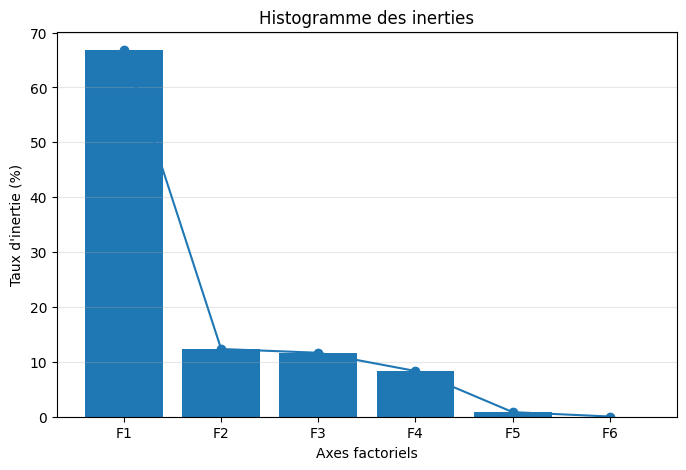

In [8]:
axes = np.arange(1, rang + 1)

plt.figure(figsize=(8, 5))
plt.bar(axes, taux_inertie)
plt.plot(axes, taux_inertie, marker="o")
plt.xticks(axes, [f"F{i}" for i in axes])
plt.xlabel("Axes factoriels")
plt.ylabel("Taux d'inertie (%)")
plt.title("Histogramme des inerties")
plt.grid(axis="y", alpha=0.3)
plt.show()

### Explication après exécution

Le graphe représente l'inertie expliquée par chaque axe.

Lorsque les premiers axes sont nettement plus élevés que les suivants, cela signifie que l'information principale est concentrée au début.  
Le critère visuel utilisé ici est proche du **critère du coude** : après le coude, les axes supplémentaires ajoutent peu d'information.

Ce graphe aide donc à justifier le choix du nombre d'axes à retenir.

## 6. Question 4 — Restriction à deux axes

In [9]:
display(Markdown(
    f"""
On se restreint au plan factoriel \\((F_1,F_2)\\) car :

- l'axe \\(F_1\\) explique **{taux_inertie[0]:.2f}%** de l'inertie totale ;
- l'axe \\(F_2\\) explique **{taux_inertie[1]:.2f}%** de l'inertie totale ;
- ensemble, les deux axes expliquent **{taux_cumules[1]:.2f}%** de l'inertie totale.

Le plan \\((F_1,F_2)\\) constitue donc un bon compromis entre réduction de dimension et conservation de l'information.
"""
))


On se restreint au plan factoriel \((F_1,F_2)\) car :

- l'axe \(F_1\) explique **66.80%** de l'inertie totale ;
- l'axe \(F_2\) explique **12.34%** de l'inertie totale ;
- ensemble, les deux axes expliquent **79.14%** de l'inertie totale.

Le plan \((F_1,F_2)\) constitue donc un bon compromis entre réduction de dimension et conservation de l'information.


### Explication après exécution

Cette cellule fournit une justification automatique du choix de deux axes.

Dans un rapport, il faut toujours justifier la réduction de dimension.  
Ici, le plan \((F_1,F_2)\) permet de représenter les profils dans un espace simple à lire tout en gardant une part importante de l'information totale.

## 7. Question 5 — Facteurs lignes

Les facteurs lignes sont les coordonnées principales des profils lignes :

$$
\Phi = D_r^{-\frac{1}{2}}U\Delta
$$

Le coefficient \(\phi_{ik}\) représente la coordonnée de la raison \(i\) sur l'axe \(k\).

In [10]:
Delta = np.diag(singular_values)

Phi = Dr_inv_sqrt @ U @ Delta

df_facteurs_lignes = pd.DataFrame(
    Phi[:, :2],
    index=raisons,
    columns=["F1", "F2"]
)

print("Facteurs lignes :")
display(df_facteurs_lignes)

Facteurs lignes :


,F1,F2
Logement,-0.1811,-0.0020
Santé,0.3751,-0.0896
Argent,-0.2898,-0.0326
Guerre,0.0794,-0.3273
Travail,0.0972,0.1022
Choix,0.1016,-0.0048
Chômage,0.1872,-0.1237


### Explication après exécution

Le tableau affiche les projections des profils lignes sur les deux premiers axes.

Une coordonnée positive ou négative indique la position de la modalité par rapport à l'origine.  
Deux raisons proches sur les axes factoriels possèdent des comportements similaires vis-à-vis des métiers.

Les raisons éloignées de l'origine sont généralement plus importantes pour l'interprétation.

## 8. Questions 6 et 7 — Facteurs colonnes et projections des profils-colonnes

Les facteurs colonnes sont les coordonnées principales des profils colonnes :

$$
\Psi = D_c^{-\frac{1}{2}}V\Delta
$$

Le coefficient \(\psi_{jk}\) représente la coordonnée du métier \(j\) sur l'axe \(k\).

In [11]:
Psi = Dc_inv_sqrt @ V @ Delta

df_facteurs_colonnes = pd.DataFrame(
    Psi[:, :2],
    index=metiers,
    columns=["F1", "F2"]
)

print("Facteurs colonnes :")
display(df_facteurs_colonnes)

print("Matrice des projections des profils-colonnes sur tous les axes :")
df_projections_colonnes = pd.DataFrame(
    Psi,
    index=metiers,
    columns=[f"F{i+1}" for i in range(rang)]
)
display(df_projections_colonnes)

Facteurs colonnes :


,F1,F2
Cadre,-0.3808,-0.2596
Libre,-0.1337,0.0283
Employé S,0.0693,0.0919
Responsable,0.3560,-0.0965
Ouvrier,-0.1892,-0.0482
Technicien,-0.1241,0.0274
Agriculteur,0.1826,-0.0336


Matrice des projections des profils-colonnes sur tous les axes :


,F1,F2,F3,F4,F5,F6
Cadre,-0.3808,-0.2596,0.1116,0.1419,-0.0040,0.0015
Libre,-0.1337,0.0283,0.0041,-0.0587,-0.0204,0.0030
Employé S,0.0693,0.0919,0.0158,0.0955,-0.0045,-0.0011
Responsable,0.3560,-0.0965,-0.0778,-0.0007,-0.0023,0.0041
Ouvrier,-0.1892,-0.0482,-0.2072,-0.0122,-0.0045,-0.0123
Technicien,-0.1241,0.0274,-0.0195,-0.0227,0.0519,0.0028
Agriculteur,0.1826,-0.0336,0.1499,-0.0791,0.0068,-0.0073


### Explication après exécution

Le premier tableau donne les coordonnées des métiers sur le plan \((F_1,F_2)\).  
Le deuxième tableau contient les projections des profils-colonnes sur tous les axes disponibles.

Pour interpréter un métier, on regarde surtout :

- son éloignement de l'origine ;
- son signe sur \(F_1\) et \(F_2\) ;
- sa proximité avec les raisons dans la carte factorielle.

## 9. Question 8 — Visualisation simultanée des deux nuages

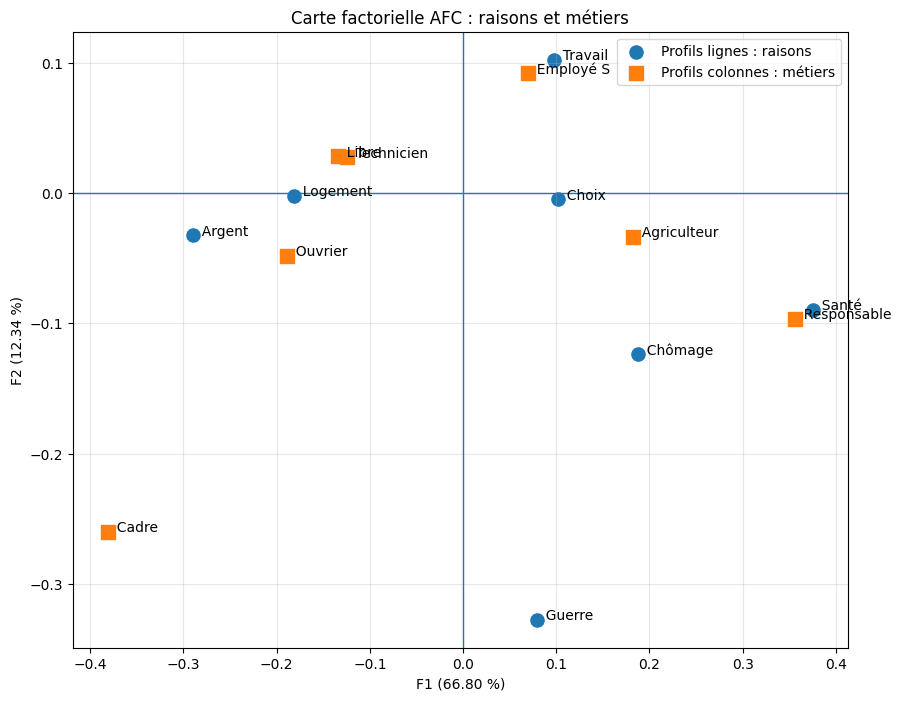

In [12]:
plt.figure(figsize=(10, 8))

plt.scatter(Phi[:, 0], Phi[:, 1], marker="o", s=90, label="Profils lignes : raisons")
for i, label in enumerate(raisons):
    plt.text(Phi[i, 0], Phi[i, 1], "  " + label, fontsize=10)

plt.scatter(Psi[:, 0], Psi[:, 1], marker="s", s=90, label="Profils colonnes : métiers")
for j, label in enumerate(metiers):
    plt.text(Psi[j, 0], Psi[j, 1], "  " + label, fontsize=10)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlabel(f"F1 ({taux_inertie[0]:.2f} %)")
plt.ylabel(f"F2 ({taux_inertie[1]:.2f} %)")
plt.title("Carte factorielle AFC : raisons et métiers")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Explication après exécution

La carte factorielle représente simultanément les raisons et les métiers.

Règles de lecture :

- deux raisons proches ont des profils similaires ;
- deux métiers proches ont des profils similaires ;
- une raison proche d'un métier indique une association possible entre les deux modalités ;
- les modalités proches de l'origine sont moins spécifiques ;
- les modalités éloignées de l'origine structurent davantage l'analyse.

Les taux affichés sous les axes indiquent la part d'inertie expliquée par chaque axe.

## 10. Question 9 — Contributions absolues et relatives des profils lignes

### Contribution absolue d'une ligne à l'axe \(k\)

$$
CTR_{ik}^{(L)} = \frac{r_i \phi_{ik}^{2}}{\lambda_k}\times 100
$$

### Contribution relative, ou qualité de représentation, sur l'axe \(k\)

$$
COS2_{ik}^{(L)} = \frac{\phi_{ik}^{2}}{d_i^2}\times 100
$$

où :

$$
d_i^2 = \sum_{j=1}^{q}\frac{\left((X_L)_{ij}-c_j\right)^2}{c_j}
$$

In [13]:
dist2_lignes = np.sum(((profils_lignes - c[None, :]) ** 2) / c[None, :], axis=1)

ctr_lignes = (r[:, None] * Phi ** 2) / valeurs_propres[None, :] * 100
cos2_lignes = (Phi ** 2) / dist2_lignes[:, None] * 100

df_ctr_lignes = pd.DataFrame(
    ctr_lignes[:, :2],
    index=raisons,
    columns=["CTR F1 (%)", "CTR F2 (%)"]
)

df_cos2_lignes = pd.DataFrame(
    cos2_lignes[:, :2],
    index=raisons,
    columns=["COS2 F1 (%)", "COS2 F2 (%)"]
)

print("Contributions absolues des profils lignes :")
display(df_ctr_lignes)

print("Contributions relatives / qualités de représentation des profils lignes :")
display(df_cos2_lignes)

Contributions absolues des profils lignes :


,CTR F1 (%),CTR F2 (%)
Logement,16.1694,0.0112
Santé,25.4052,7.8524
Argent,39.7399,2.7211
Guerre,0.3480,32.0019
Travail,7.0207,41.9701
Choix,4.8125,0.0573
Chômage,6.5044,15.3861


Contributions relatives / qualités de représentation des profils lignes :


,COS2 F1 (%),COS2 F2 (%)
Logement,83.3948,0.0107
Santé,75.6699,4.3192
Argent,90.2359,1.1410
Guerre,3.3760,57.3393
Travail,45.1551,49.8504
Choix,31.2582,0.0687
Chômage,56.8706,24.8432


### Explication après exécution

Le tableau **CTR** indique quelles raisons participent le plus à la construction des axes.  
Une raison avec une contribution élevée sur \(F_1\) joue un rôle important dans la formation du premier axe.

Le tableau **COS2** indique la qualité de représentation.  
Une valeur élevée signifie que la modalité est bien représentée sur l'axe.  
Une valeur faible signifie que la modalité est plutôt expliquée par d'autres axes.

## 11. Question 10 — Contributions absolues et relatives des profils colonnes

### Contribution absolue d'une colonne à l'axe \(k\)

$$
CTR_{jk}^{(C)} = \frac{c_j \psi_{jk}^{2}}{\lambda_k}\times 100
$$

### Contribution relative, ou qualité de représentation, sur l'axe \(k\)

$$
COS2_{jk}^{(C)} = \frac{\psi_{jk}^{2}}{d_j^2}\times 100
$$

où :

$$
d_j^2 = \sum_{i=1}^{p}\frac{\left((X_C)_{ij}-r_i\right)^2}{r_i}
$$

In [14]:
dist2_colonnes = np.sum(((profils_colonnes.T - r[None, :]) ** 2) / r[None, :], axis=1)

ctr_colonnes = (c[:, None] * Psi ** 2) / valeurs_propres[None, :] * 100
cos2_colonnes = (Psi ** 2) / dist2_colonnes[:, None] * 100

df_ctr_colonnes = pd.DataFrame(
    ctr_colonnes[:, :2],
    index=metiers,
    columns=["CTR F1 (%)", "CTR F2 (%)"]
)

df_cos2_colonnes = pd.DataFrame(
    cos2_colonnes[:, :2],
    index=metiers,
    columns=["COS2 F1 (%)", "COS2 F2 (%)"]
)

print("Contributions absolues des profils colonnes :")
display(df_ctr_colonnes)

print("Contributions relatives / qualités de représentation des profils colonnes :")
display(df_cos2_colonnes)

Contributions absolues des profils colonnes :


,CTR F1 (%),CTR F2 (%)
Cadre,18.4245,46.3892
Libre,13.0235,3.1531
Employé S,2.8678,27.2966
Responsable,45.1375,17.9726
Ouvrier,5.9272,2.0856
Technicien,5.2500,1.3853
Agriculteur,9.3695,1.7176


Contributions relatives / qualités de représentation des profils colonnes :


,COS2 F1 (%),COS2 F2 (%)
Cadre,59.1742,27.5141
Libre,79.2195,3.5420
Employé S,21.2269,37.3118
Responsable,89.1707,6.5568
Ouvrier,43.9919,2.8586
Technicien,77.9754,3.7996
Agriculteur,52.6998,1.7841


### Explication après exécution

Pour les profils colonnes, l'interprétation est identique à celle des profils lignes.

Le tableau **CTR** montre les métiers qui construisent fortement les axes.  
Le tableau **COS2** montre si chaque métier est bien représenté sur \(F_1\), sur \(F_2\), ou plutôt sur d'autres axes.

Un métier très contributif et bien représenté est très important pour l'analyse du plan factoriel.

## 12. Interprétation automatique des contributions

In [15]:
def top_modalites(labels, ctr, coords, axe, nombre=4):
    ordre = np.argsort(ctr[:, axe])[::-1][:nombre]
    lignes = []
    for i in ordre:
        lignes.append({
            "Modalité": labels[i],
            "Coordonnée": coords[i, axe],
            "CTR (%)": ctr[i, axe],
            "Signe": "positif" if coords[i, axe] > 0 else "négatif"
        })
    return pd.DataFrame(lignes)

top_lignes_F1 = top_modalites(raisons, ctr_lignes, Phi, 0)
top_colonnes_F1 = top_modalites(metiers, ctr_colonnes, Psi, 0)

top_lignes_F2 = top_modalites(raisons, ctr_lignes, Phi, 1)
top_colonnes_F2 = top_modalites(metiers, ctr_colonnes, Psi, 1)

print("Raisons qui contribuent le plus à F1 :")
display(top_lignes_F1)

print("Métiers qui contribuent le plus à F1 :")
display(top_colonnes_F1)

print("Raisons qui contribuent le plus à F2 :")
display(top_lignes_F2)

print("Métiers qui contribuent le plus à F2 :")
display(top_colonnes_F2)

Raisons qui contribuent le plus à F1 :


,Modalité,Coordonnée,CTR (%),Signe
0,Argent,-0.2898,39.7399,négatif
1,Santé,0.3751,25.4052,positif
2,Logement,-0.1811,16.1694,négatif
3,Travail,0.0972,7.0207,positif


Métiers qui contribuent le plus à F1 :


,Modalité,Coordonnée,CTR (%),Signe
0,Responsable,0.3560,45.1375,positif
1,Cadre,-0.3808,18.4245,négatif
2,Libre,-0.1337,13.0235,négatif
3,Agriculteur,0.1826,9.3695,positif


Raisons qui contribuent le plus à F2 :


,Modalité,Coordonnée,CTR (%),Signe
0,Travail,0.1022,41.9701,positif
1,Guerre,-0.3273,32.0019,négatif
2,Chômage,-0.1237,15.3861,négatif
3,Santé,-0.0896,7.8524,négatif


Métiers qui contribuent le plus à F2 :


,Modalité,Coordonnée,CTR (%),Signe
0,Cadre,-0.2596,46.3892,négatif
1,Employé S,0.0919,27.2966,positif
2,Responsable,-0.0965,17.9726,négatif
3,Libre,0.0283,3.1531,positif


### Explication après exécution

Cette cellule classe automatiquement les modalités les plus contributives.

Pour chaque axe, il faut observer :

- les modalités qui ont les plus fortes contributions ;
- le signe de leurs coordonnées ;
- les oppositions entre les modalités positives et négatives.

L'axe \(F_1\) oppose généralement les modalités situées à gauche et à droite de la carte factorielle.  
L'axe \(F_2\) oppose les modalités situées en haut et en bas.

## 13. Question 11 — Modalités mal représentées sur le plan factoriel

Une modalité est considérée comme mal représentée sur le plan \((F_1,F_2)\) si :

$$
COS2(F_1,F_2) = COS2(F_1) + COS2(F_2)
$$

est faible.

Dans ce notebook, on utilise le seuil suivant :

$$
COS2(F_1,F_2) < 50\%
$$

In [16]:
seuil = 50

qualite_lignes_plan = cos2_lignes[:, :2].sum(axis=1)
qualite_colonnes_plan = cos2_colonnes[:, :2].sum(axis=1)

df_qualite_lignes_plan = pd.DataFrame({
    "COS2 sur le plan F1-F2 (%)": qualite_lignes_plan,
    "Décision": np.where(qualite_lignes_plan < seuil, "Mal représentée", "Bien représentée")
}, index=raisons)

df_qualite_colonnes_plan = pd.DataFrame({
    "COS2 sur le plan F1-F2 (%)": qualite_colonnes_plan,
    "Décision": np.where(qualite_colonnes_plan < seuil, "Mal représentée", "Bien représentée")
}, index=metiers)

print("Qualité de représentation des raisons sur le plan F1-F2 :")
display(df_qualite_lignes_plan)

print("Qualité de représentation des métiers sur le plan F1-F2 :")
display(df_qualite_colonnes_plan)

Qualité de représentation des raisons sur le plan F1-F2 :


,COS2 sur le plan F1-F2 (%),Décision
Logement,83.4054,Bien représentée
Santé,79.9891,Bien représentée
Argent,91.3770,Bien représentée
Guerre,60.7153,Bien représentée
Travail,95.0055,Bien représentée
Choix,31.3269,Mal représentée
Chômage,81.7137,Bien représentée


Qualité de représentation des métiers sur le plan F1-F2 :


,COS2 sur le plan F1-F2 (%),Décision
Cadre,86.6882,Bien représentée
Libre,82.7615,Bien représentée
Employé S,58.5386,Bien représentée
Responsable,95.7275,Bien représentée
Ouvrier,46.8506,Mal représentée
Technicien,81.7750,Bien représentée
Agriculteur,54.4839,Bien représentée


### Explication après exécution

Les modalités marquées **mal représentées** ne doivent pas être interprétées fortement à partir du plan \((F_1,F_2)\).  
Elles peuvent être mieux expliquées par un troisième axe ou par les axes suivants.

Les modalités **bien représentées** peuvent être interprétées directement à partir de la carte factorielle.

## 14. Question 12 — Modalités contribuant fortement au premier axe

In [17]:
seuil_contribution_lignes = 100 / len(raisons)
seuil_contribution_colonnes = 100 / len(metiers)

fortes_lignes_F1 = df_ctr_lignes[df_ctr_lignes["CTR F1 (%)"] > seuil_contribution_lignes].copy()
fortes_colonnes_F1 = df_ctr_colonnes[df_ctr_colonnes["CTR F1 (%)"] > seuil_contribution_colonnes].copy()

fortes_lignes_F1["Coordonnée F1"] = df_facteurs_lignes.loc[fortes_lignes_F1.index, "F1"]
fortes_colonnes_F1["Coordonnée F1"] = df_facteurs_colonnes.loc[fortes_colonnes_F1.index, "F1"]

print("Raisons contribuant fortement à F1 :")
display(fortes_lignes_F1)

print("Situations sociales contribuant fortement à F1 :")
display(fortes_colonnes_F1)

Raisons contribuant fortement à F1 :


,CTR F1 (%),CTR F2 (%),Coordonnée F1
Logement,16.1694,0.0112,-0.1811
Santé,25.4052,7.8524,0.3751
Argent,39.7399,2.7211,-0.2898


Situations sociales contribuant fortement à F1 :


,CTR F1 (%),CTR F2 (%),Coordonnée F1
Cadre,18.4245,46.3892,-0.3808
Responsable,45.1375,17.9726,0.3560


### Explication après exécution

Le seuil moyen de contribution est :

$$
\frac{100}{\text{nombre de modalités}}
$$

Une modalité qui dépasse ce seuil contribue plus que la moyenne à la construction de l'axe.

Les raisons et métiers affichés dans ces deux tableaux sont donc les plus importants pour interpréter le premier axe factoriel.

## 15. Question 13 — Analyse et interprétation globale

In [18]:
f1_pos_raisons = [raisons[i] for i in np.where(Phi[:, 0] > 0)[0]]
f1_neg_raisons = [raisons[i] for i in np.where(Phi[:, 0] < 0)[0]]
f1_pos_metiers = [metiers[j] for j in np.where(Psi[:, 0] > 0)[0]]
f1_neg_metiers = [metiers[j] for j in np.where(Psi[:, 0] < 0)[0]]

f2_pos_raisons = [raisons[i] for i in np.where(Phi[:, 1] > 0)[0]]
f2_neg_raisons = [raisons[i] for i in np.where(Phi[:, 1] < 0)[0]]
f2_pos_metiers = [metiers[j] for j in np.where(Psi[:, 1] > 0)[0]]
f2_neg_metiers = [metiers[j] for j in np.where(Psi[:, 1] < 0)[0]]

display(Markdown(f"""
**Synthèse automatique**

Sur le premier axe \\(F_1\\) :

- raisons du côté positif : **{", ".join(f1_pos_raisons)}** ;
- raisons du côté négatif : **{", ".join(f1_neg_raisons)}** ;
- métiers du côté positif : **{", ".join(f1_pos_metiers)}** ;
- métiers du côté négatif : **{", ".join(f1_neg_metiers)}**.

Sur le deuxième axe \\(F_2\\) :

- raisons du côté positif : **{", ".join(f2_pos_raisons)}** ;
- raisons du côté négatif : **{", ".join(f2_neg_raisons)}** ;
- métiers du côté positif : **{", ".join(f2_pos_metiers)}** ;
- métiers du côté négatif : **{", ".join(f2_neg_metiers)}**.
"""))


**Synthèse automatique**

Sur le premier axe \(F_1\) :

- raisons du côté positif : **Santé, Guerre, Travail, Choix, Chômage** ;
- raisons du côté négatif : **Logement, Argent** ;
- métiers du côté positif : **Employé S, Responsable, Agriculteur** ;
- métiers du côté négatif : **Cadre, Libre, Ouvrier, Technicien**.

Sur le deuxième axe \(F_2\) :

- raisons du côté positif : **Travail** ;
- raisons du côté négatif : **Logement, Santé, Argent, Guerre, Choix, Chômage** ;
- métiers du côté positif : **Libre, Employé S, Technicien** ;
- métiers du côté négatif : **Cadre, Responsable, Ouvrier, Agriculteur**.


### Explication après exécution

L'interprétation globale se fait en observant les oppositions entre les deux côtés des axes.

Le premier axe \(F_1\) explique la plus grande part de l'inertie.  
Les modalités qui contribuent fortement à \(F_1\) permettent de donner un sens à cet axe.

Le deuxième axe \(F_2\) apporte une information complémentaire.  
Il permet souvent de distinguer des profils qui ne sont pas séparés par \(F_1\).

Dans le rapport, il faut insister surtout sur les modalités qui sont :

- éloignées de l'origine ;
- bien représentées sur le plan ;
- fortement contributives.

## 16. Vérification par le khi-deux

En AFC, l'inertie totale est liée au test du khi-deux par la relation :

$$
I = \frac{\chi^2}{N}
$$

donc :

$$
\chi^2 = N \times I
$$

In [19]:
inertie_totale = valeurs_propres.sum()
chi2 = N * inertie_totale

print("Inertie totale =", round(inertie_totale, 6))
print("Khi-deux =", round(chi2, 6))
print("Effectif total N =", int(N))

Inertie totale = 0.057647
Khi-deux = 89.526381
Effectif total N = 1553


### Explication après exécution

Cette vérification confirme le lien entre l'AFC et le test du khi-deux.

Une inertie totale élevée signifie que l'écart entre le tableau observé et le tableau théorique d'indépendance est important.  
Autrement dit, les raisons et les métiers ne sont pas distribués de façon totalement indépendante.

## 17. Sauvegarde optionnelle des résultats

In [20]:
df_F.to_csv("AFC_frequences_relatives.csv", encoding="utf-8-sig")
df_profils_lignes.to_csv("AFC_profils_lignes.csv", encoding="utf-8-sig")
df_profils_colonnes.to_csv("AFC_profils_colonnes.csv", encoding="utf-8-sig")
df_inertie.to_csv("AFC_inerties.csv", encoding="utf-8-sig")
df_facteurs_lignes.to_csv("AFC_facteurs_lignes.csv", encoding="utf-8-sig")
df_facteurs_colonnes.to_csv("AFC_facteurs_colonnes.csv", encoding="utf-8-sig")
df_ctr_lignes.to_csv("AFC_contributions_lignes.csv", encoding="utf-8-sig")
df_ctr_colonnes.to_csv("AFC_contributions_colonnes.csv", encoding="utf-8-sig")

print("Fichiers CSV sauvegardés.")

Fichiers CSV sauvegardés.


### Explication après exécution

Cette cellule sauvegarde les principaux résultats sous forme de fichiers CSV.

Elle est utile si vous souhaitez intégrer les tableaux dans un rapport Word ou PDF :

- fréquences relatives ;
- profils lignes ;
- profils colonnes ;
- inerties ;
- facteurs lignes ;
- facteurs colonnes ;
- contributions.

## Conclusion du rapport

Ce TP applique une **Analyse Factorielle des Correspondances** à un tableau croisant les raisons de non-parentalité et les catégories sociales.

La démarche suivie est :

1. construction du tableau de contingence ;
2. calcul des fréquences relatives ;
3. calcul des profils lignes et colonnes ;
4. construction de la matrice standardisée ;
5. extraction des valeurs propres et des taux d'inertie ;
6. représentation des modalités dans le plan factoriel ;
7. calcul des contributions et des qualités de représentation ;
8. interprétation des associations entre raisons et métiers.

Cette méthode permet de visualiser les proximités entre modalités et d'identifier les oppositions principales présentes dans les données.